# Lab 02 · Parte 2 — Relación Jugador → Club → Temporada (Python)

En la parte 1 cada club era un **conjunto** de jugadores. Ahora recuperamos la información que se perdió al eliminar duplicados: **en qué temporadas** estuvo cada jugador en cada club.

La relación es un conjunto de tripletas

$$R = \{(\text{jugador}, \text{club}, \text{temporada})\} \subseteq J \times C \times T$$

donde $J$ son los jugadores, $C = \{\text{Atlético}, \text{Barcelona}\}$ y $T$ las 20 temporadas (2004-05 a 2023-24). El club y la temporada no están dentro de los CSV: se extraen del **nombre del archivo** (`atletico_2014-15.csv`).

La representamos de tres formas: **tabla**, **diccionario** (lista en R) y **grafo simple**.

In [1]:
from pathlib import Path
import re
import unicodedata

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = Path("/home/jovyan/datasets/lab02/futbol_data")
if not DATA_DIR.exists():
    DATA_DIR = Path("../../datasets/lab02/futbol_data")

CLUBES = {"atletico": "Atlético", "barcelona": "Barcelona"}
PATRON = re.compile(r"(?P<club>[a-z]+)_(?P<temporada>\d{4}-\d{2})\.csv")


def clave_alfabetica(nombre):
    return unicodedata.normalize("NFKD", nombre).encode("ascii", "ignore").decode().casefold()

## 1. Construir la relación completa

Por cada archivo se leen sus jugadores y se añaden el club y la temporada que indica su nombre.

In [2]:
def leer_temporada(archivo):
    partes = PATRON.fullmatch(archivo.name)
    plantilla = pd.read_csv(archivo, encoding="utf-8-sig")
    return pd.DataFrame({
        "jugador": plantilla["jugador"].str.strip(),
        "club": CLUBES[partes["club"]],
        "temporada": partes["temporada"],
    })


relacion = pd.concat(
    (leer_temporada(f) for f in sorted(DATA_DIR.glob("*.csv"))),
    ignore_index=True,
)
assert not relacion.duplicated().any(), "Hay tripletas repetidas"

print(f"{len(relacion)} tripletas (jugador, club, temporada)")
print(f"{relacion['jugador'].nunique()} jugadores · {relacion['club'].nunique()} clubes · "
      f"{relacion['temporada'].nunique()} temporadas")

551 tripletas (jugador, club, temporada)
108 jugadores · 2 clubes · 20 temporadas


## 2. Tres representaciones

### 2a. Tabla

Cada fila es un elemento de la relación. Primeras filas y un ejemplo con los 3 jugadores que pasaron por ambos clubes:

In [3]:
relacion.head(10)

,jugador,club,temporada
0,Antonio López,Atlético,2004-05
1,Colsa,Atlético,2004-05
2,Fernando Torres,Atlético,2004-05
3,García Calvo,Atlético,2004-05
4,Ibagaza,Atlético,2004-05
5,Jorge Larena,Atlético,2004-05
6,Juan Valera,Atlético,2004-05
7,Juan Velasco,Atlético,2004-05
8,Leo Franco,Atlético,2004-05
9,Luis Perea,Atlético,2004-05


In [4]:
compartidos = ["Antoine Griezmann", "David Villa", "João Félix"]
(relacion[relacion["jugador"].isin(compartidos)]
 .sort_values(["jugador", "temporada"])
 .reset_index(drop=True))

,jugador,club,temporada
0,Antoine Griezmann,Atlético,2014-15
1,Antoine Griezmann,Atlético,2015-16
2,Antoine Griezmann,Atlético,2016-17
3,Antoine Griezmann,Atlético,2017-18
4,Antoine Griezmann,Atlético,2018-19
5,Antoine Griezmann,Barcelona,2019-20
6,Antoine Griezmann,Barcelona,2020-21
7,Antoine Griezmann,Atlético,2021-22
8,Antoine Griezmann,Atlético,2022-23
9,Antoine Griezmann,Atlético,2023-24


Vista resumida de la tabla: temporadas de cada jugador en cada club.

In [5]:
tabla_resumen = (relacion
                 .groupby(["jugador", "club"])["temporada"]
                 .agg(temporadas="count", primera="min", ultima="max")
                 .reset_index()
                 .sort_values("temporadas", ascending=False, kind="stable"))
tabla_resumen.head(10)

,jugador,club,temporadas,primera,ultima
54,Lionel Messi,Barcelona,17,2004-05,2020-21
3,Andrés Iniesta,Barcelona,15,2004-05,2018-19
91,Sergio Busquets,Barcelona,15,2008-09,2022-23
30,Gerard Piqué,Barcelona,14,2008-09,2021-22
51,Koke Resurrección,Atlético,13,2011-12,2023-24
10,Carles Puyol,Barcelona,11,2004-05,2014-15
40,Jordi Alba,Barcelona,11,2012-13,2022-23
88,Saúl Ñíguez,Atlético,11,2013-14,2023-24
101,Víctor Valdés,Barcelona,11,2004-05,2014-15
102,Xavi Hernández,Barcelona,11,2004-05,2014-15


### 2b. Diccionario

Estructura anidada `{jugador: {club: [temporadas]}}`: se consulta directamente por nombre.

In [6]:
diccionario = {}
for fila in relacion.sort_values("temporada").itertuples(index=False):
    diccionario.setdefault(fila.jugador, {}).setdefault(fila.club, []).append(fila.temporada)

print(len(diccionario), "jugadores en el diccionario\n")
for jugador in compartidos + ["Lionel Messi"]:
    print(f"{jugador!r}: {diccionario[jugador]}")

108 jugadores en el diccionario

'Antoine Griezmann': {'Atlético': ['2014-15', '2015-16', '2016-17', '2017-18', '2018-19', '2021-22', '2022-23', '2023-24'], 'Barcelona': ['2019-20', '2020-21']}
'David Villa': {'Barcelona': ['2010-11', '2011-12', '2012-13'], 'Atlético': ['2013-14', '2014-15']}
'João Félix': {'Atlético': ['2019-20', '2020-21', '2021-22', '2022-23'], 'Barcelona': ['2023-24']}
'Lionel Messi': {'Barcelona': ['2004-05', '2005-06', '2006-07', '2007-08', '2008-09', '2009-10', '2010-11', '2011-12', '2012-13', '2013-14', '2014-15', '2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21']}


### 2c. Grafo simple

Un **grafo simple** no tiene aristas repetidas ni bucles. Para que lo sea, la relación ternaria se proyecta en un grafo **bipartito**:

- **Nodos:** los 108 jugadores y los 2 clubes.
- **Aristas:** una única arista jugador–club si el jugador estuvo en ese club, aunque fuera varias temporadas.
- **Peso de la arista:** el número de temporadas. Así la tercera componente (temporada) no se pierde.

En el dibujo, los jugadores exclusivos de cada club rodean a su club y los 3 compartidos quedan en el centro, conectados a ambos. Solo se rotulan los compartidos y los que tienen 10 temporadas o más.

In [7]:
pesos = relacion.groupby(["jugador", "club"]).size()

grafo = nx.Graph()
grafo.add_nodes_from(CLUBES.values(), tipo="club")
grafo.add_nodes_from(relacion["jugador"].unique(), tipo="jugador")
for (jugador, club), temporadas in pesos.items():
    grafo.add_edge(jugador, club, temporadas=temporadas)

print(f"Nodos: {grafo.number_of_nodes()} · Aristas: {grafo.number_of_edges()}")
print("¿Grafo simple (sin bucles)?", nx.number_of_selfloops(grafo) == 0)
print("Jugadores conectados a los dos clubes:",
      sorted(n for n in grafo if grafo.nodes[n]["tipo"] == "jugador" and grafo.degree(n) == 2))

Nodos: 110 · Aristas: 111
¿Grafo simple (sin bucles)? True
Jugadores conectados a los dos clubes: ['Antoine Griezmann', 'David Villa', 'João Félix']


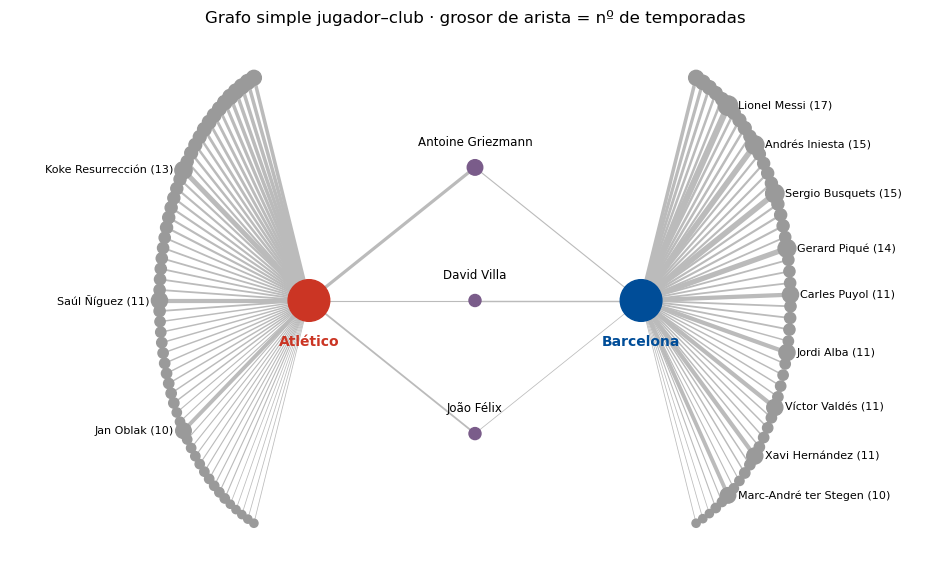

In [8]:
def posiciones(grafo):
    """Clubes a izquierda y derecha, sus exclusivos en abanico y los compartidos en el centro."""
    pos = {"Atlético": (-1.0, 0.0), "Barcelona": (1.0, 0.0)}
    jugadores = [n for n in grafo if grafo.nodes[n]["tipo"] == "jugador"]
    centro = sorted((j for j in jugadores if grafo.degree(j) == 2), key=clave_alfabetica)
    for i, j in enumerate(centro):
        pos[j] = (0.0, 0.5 - i * 0.5)
    for club, lado in (("Atlético", -1), ("Barcelona", 1)):
        exclusivos = sorted((j for j in grafo[club] if grafo.degree(j) == 1),
                            key=lambda j: -grafo[j][club]["temporadas"])
        destacados = [j for j in exclusivos if grafo[j][club]["temporadas"] >= 10]
        resto = [j for j in exclusivos if j not in destacados]
        # Los destacados se reparten a lo largo del abanico para que sus etiquetas no se solapen
        huecos = np.linspace(0, len(exclusivos) - 1, len(destacados) + 2)[1:-1].round().astype(int)
        orden = resto.copy()
        for h, j in zip(huecos, destacados):
            orden.insert(h, j)
        angulos = np.linspace(np.pi * 0.62, np.pi * 1.38, len(orden))
        for j, a in zip(orden, angulos):
            pos[j] = (pos[club][0] - lado * 0.9 * np.cos(a), 0.9 * np.sin(a))
    return pos


pos = posiciones(grafo)
anchos = [0.3 + grafo[u][v]["temporadas"] * 0.25 for u, v in grafo.edges]
colores_nodo = ["#CB3524" if n == "Atlético" else "#004D98" if n == "Barcelona"
                else "#7a5c8a" if grafo.degree(n) == 2 else "#9a9a9a" for n in grafo]
tamanos = [900 if grafo.nodes[n]["tipo"] == "club" else 25 + 10 * sum(d["temporadas"] for d in grafo[n].values())
           for n in grafo]
etiquetas = {n: n for n in grafo
             if grafo.nodes[n]["tipo"] == "club" or grafo.degree(n) == 2
             or sum(d["temporadas"] for d in grafo[n].values()) >= 10}

fig, ax = plt.subplots(figsize=(12, 7))
nx.draw_networkx_edges(grafo, pos, width=anchos, edge_color="#bbbbbb", ax=ax)
nx.draw_networkx_nodes(grafo, pos, node_color=colores_nodo, node_size=tamanos, ax=ax)
for nodo in etiquetas:
    x, y = pos[nodo]
    if grafo.nodes[nodo]["tipo"] == "club":
        ax.text(x, y - 0.13, nodo, ha="center", va="top", fontsize=10, weight="bold",
                color="#CB3524" if nodo == "Atlético" else "#004D98")
    elif grafo.degree(nodo) == 2:
        ax.text(x, y + 0.07, nodo, ha="center", va="bottom", fontsize=8.5)
    else:
        temporadas = sum(d["temporadas"] for d in grafo[nodo].values())
        ax.text(x + (0.06 if x > 0 else -0.06), y, f"{nodo} ({temporadas})",
                ha="left" if x > 0 else "right", va="center", fontsize=8)
ax.set_title("Grafo simple jugador–club · grosor de arista = nº de temporadas")
ax.set_xlim(-2.8, 2.8)
ax.axis("off")
plt.show()

## 3. Preguntas

### ¿Qué jugadores tienen más temporadas?

Se cuentan las temporadas de cada jugador sumando ambos clubes.

In [9]:
temporadas_por_jugador = (relacion
                          .groupby("jugador")
                          .agg(temporadas=("temporada", "count"),
                               clubes=("club", lambda c: " + ".join(sorted(c.unique()))))
                          .sort_values("temporadas", ascending=False, kind="stable"))
temporadas_por_jugador.head(10)

,temporadas,clubes
jugador,,
Lionel Messi,17,Barcelona
Andrés Iniesta,15,Barcelona
Sergio Busquets,15,Barcelona
Gerard Piqué,14,Barcelona
Koke Resurrección,13,Atlético
Carles Puyol,11,Barcelona
Jordi Alba,11,Barcelona
Saúl Ñíguez,11,Atlético
Víctor Valdés,11,Barcelona


In [10]:
maximo = temporadas_por_jugador["temporadas"].max()
lideres = temporadas_por_jugador[temporadas_por_jugador["temporadas"] == maximo].index.tolist()
print(f"Más temporadas: {', '.join(lideres)} con {maximo}")

Más temporadas: Lionel Messi con 17


### ¿Qué relación es más densa: Club A o Club B?

Se define la **densidad** de la relación de cada club como la proporción de la matriz jugador × temporada que está ocupada:

$$\text{densidad}(c) = \frac{|R_c|}{|J_c| \cdot |T|}$$

Es la densidad del grafo bipartito jugador–temporada de ese club: 1 significaría que todos sus jugadores estuvieron las 20 temporadas. Una densidad mayor indica una **plantilla más estable**, con jugadores que permanecen más años.

In [11]:
total_temporadas = relacion["temporada"].nunique()
densidad = (relacion
            .groupby("club")
            .agg(pares=("jugador", "size"), jugadores=("jugador", "nunique"))
            .assign(temporadas=total_temporadas))
densidad["densidad"] = densidad["pares"] / (densidad["jugadores"] * densidad["temporadas"])
densidad["temporadas_por_jugador"] = densidad["pares"] / densidad["jugadores"]
densidad.round(3)

,pares,jugadores,temporadas,densidad,temporadas_por_jugador
club,,,,,
Atlético,264,58,20,0.228,4.552
Barcelona,287,53,20,0.271,5.415


In [12]:
mas_densa = densidad["densidad"].idxmax()
print(f"Relación más densa: {mas_densa} ({densidad.loc[mas_densa, 'densidad']:.3f})")

Relación más densa: Barcelona (0.271)


## Conclusiones

- La relación completa tiene **551 tripletas** (264 del Atlético y 287 del Barcelona), sin duplicados.
- **Lionel Messi** es el jugador con más temporadas (**17**, todas en el Barcelona), seguido de **Andrés Iniesta** y **Sergio Busquets** (15) y **Gerard Piqué** (14).
- El grafo simple tiene **110 nodos** (108 jugadores y 2 clubes) y **111 aristas**: 108 jugadores, más una arista extra por cada uno de los 3 que jugaron en ambos clubes.
- El **Barcelona** tiene la relación más densa (**0,271** frente a **0,228**): sus jugadores permanecen de media **5,42** temporadas, frente a **4,55** en el Atlético. Es decir, con menos jugadores distintos (53 frente a 58) ha cubierto más plazas de plantilla.